#  Visualization Suite — with Best-Condition Highlighting

This version adds a small visual cue to mark the **best condition in each panel**.

## What is new
A **star symbol (★)** is added to highlight the best condition according to a configurable rule.

## Best-condition rules
At the top of the notebook, you can define whether each metric should be interpreted as:

- `"max"` → larger is better
- `"min"` → smaller is better

This is important because:
- for **VAI, Time spent, Fixations, Revisits**, higher is usually more desirable
- for **TTFF**, lower is usually better
- for **Fix. duration, FFD, K-coefficient**, interpretation can be more study-dependent

So the notebook makes the rule **fully editable**.

## Figures created
### Figure family A — raincloud grids
- `_raincloud_best_CTA.pdf`
- `_raincloud_best_Headline.pdf`
- `_raincloud_best_Product.pdf`

### Figure family B — effect-profile overview
- `_effect_profile_best_all_AOIs.pdf`

In both figure families, the best condition is visually emphasized with a star.


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from scipy import stats
from scipy.stats import gaussian_kde


## 1. Configuration

In [11]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"

CONDITION_ORDER = ["A", "B", "C", "D", "E"]
AOIS = ["CTA", "Headline", "Product"]

METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "FFD (s)",
    "K-coefficient",
    "Revisits",
]

# ---------------------------------------------------------
# IMPORTANT: define how "best" is chosen for each metric
# ---------------------------------------------------------
BEST_RULES = {
    "VAI (%)": "max",
    "TTFF (s)": "min",
    "Time spent (s)": "max",
    "Fixations": "max",
    "Fix. duration (s)": "min",
    "FFD (s)": "min",
    "K-coefficient": "max",
    "Revisits": "max",
}

RANDOM_SEED = 42
N_BOOTSTRAP = 5000

RAIN_PREFIX = "_raincloud_best"
EFFECT_PROFILE_PDF = "_effect_profile_best_all_AOIs.pdf"
EFFECT_PROFILE_PNG = "_effect_profile_best_all_AOIs.png"


## 2. Load data

In [12]:
if not Path(LONG_CSV).exists():
    raise FileNotFoundError(f"Could not find {LONG_CSV}")

df = pd.read_csv(LONG_CSV)
df.columns = [str(c).replace("**", "").strip() for c in df.columns]

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

print("Rows:", len(df))
print("AOIs:", sorted(df["AOI"].unique()))
print("Metrics:", sorted(df["metric"].unique()))


Rows: 2320
AOIs: ['CTA', 'Headline', 'Product']
Metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']


## 3. Shared helpers

In [13]:
def get_focus(aoi, metric):
    return df[
        (df["AOI"] == aoi)
        & (df["metric"] == metric)
        & (df["condition"].isin(CONDITION_ORDER))
    ].copy()


def get_summary(focus):
    rows = []

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[focus["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .values
        )

        n = len(vals)

        if n == 0:
            rows.append({
                "condition": cond,
                "n": 0,
                "mean": np.nan,
                "ci95": np.nan,
                "lower": np.nan,
                "upper": np.nan,
            })
            continue

        mean = np.mean(vals)

        if n > 1:
            sd = np.std(vals, ddof=1)
            se = sd / np.sqrt(n)
            ci = stats.t.ppf(0.975, n - 1) * se
        else:
            ci = np.nan

        rows.append({
            "condition": cond,
            "n": n,
            "mean": mean,
            "ci95": ci,
            "lower": mean - ci if np.isfinite(ci) else np.nan,
            "upper": mean + ci if np.isfinite(ci) else np.nan,
        })

    return pd.DataFrame(rows)


def get_pivot(focus):
    return (
        focus.pivot(index="Img", columns="condition", values="value")
        .reindex(columns=CONDITION_ORDER)
    )


def paired_dz(x, y):
    d = np.asarray(y, dtype=float) - np.asarray(x, dtype=float)
    d = d[np.isfinite(d)]

    if len(d) < 2:
        return np.nan

    sd = np.std(d, ddof=1)

    if sd == 0:
        return 0.0

    return np.mean(d) / sd


def bootstrap_dz(x, y, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan, np.nan, np.nan

    obs = paired_dz(x, y)

    rng = np.random.default_rng(seed)
    boot = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(x), size=len(x))
        dz = paired_dz(x[idx], y[idx])

        if np.isfinite(dz):
            boot.append(dz)

    if len(boot) == 0:
        return obs, np.nan, np.nan

    lo, hi = np.percentile(boot, [2.5, 97.5])

    return obs, lo, hi


def get_best_condition(summary, metric):
    """
    Returns the best condition based on the rule in BEST_RULES.
    """
    rule = BEST_RULES.get(metric, "max")

    tmp = summary[["condition", "mean"]].dropna().copy()

    if len(tmp) == 0:
        return None

    if rule == "min":
        idx = tmp["mean"].idxmin()
    else:
        idx = tmp["mean"].idxmax()

    return tmp.loc[idx, "condition"]


def get_best_profile_condition(sub_effects, metric):
    """
    In the effect-profile figure, choose the best among B/C/D/E
    according to the metric direction.
    """
    rule = BEST_RULES.get(metric, "max")
    tmp = sub_effects[sub_effects["metric"] == metric].dropna(subset=["dz"]).copy()

    if len(tmp) == 0:
        return None

    if rule == "min":
        # Lower than A is better -> more negative dz is better
        idx = tmp["dz"].idxmin()
    else:
        # Higher than A is better -> more positive dz is better
        idx = tmp["dz"].idxmax()

    return tmp.loc[idx, "condition"]


# Figure family A — raincloud grids with best-condition stars


In [14]:
def draw_half_violin(ax, x, values, color, side="right", width=0.20, alpha=0.16):
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) < 3 or np.std(vals) == 0:
        return

    kde = gaussian_kde(vals)

    y = np.linspace(vals.min(), vals.max(), 160)
    density = kde(y)

    if density.max() > 0:
        density = density / density.max() * width

    if side == "right":
        x1 = np.full_like(y, x)
        x2 = x + density
    else:
        x1 = x - density
        x2 = np.full_like(y, x)

    ax.fill_betweenx(
        y, x1, x2,
        color=color,
        alpha=alpha,
        linewidth=0,
        zorder=1
    )


def draw_best_star(ax, x, y, color, label=None):
    ax.text(
        x, y, "★",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=color,
        zorder=10,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),
            pe.Normal()
        ]
    )

    if label is not None:
        ax.text(
            x,
            y + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            label,
            ha="center",
            va="bottom",
            fontsize=6.8,
            color=color,
            zorder=10,
            bbox=dict(
                boxstyle="round,pad=0.14",
                facecolor="white",
                edgecolor="none",
                alpha=0.92
            )
        )


def draw_raincloud_panel(ax, aoi, metric, panel_idx, condition_colors):
    focus = get_focus(aoi, metric)

    if focus.empty:
        ax.set_visible(False)
        return

    summary = get_summary(focus)
    pivot = get_pivot(focus)

    x_positions = {c: i for i, c in enumerate(CONDITION_ORDER)}

    ax.axvspan(
        x_positions["C"] - 0.31,
        x_positions["C"] + 0.31,
        alpha=0.025,
        zorder=0
    )

    complete = pivot.dropna()

    for _, row in complete.iterrows():
        ax.plot(
            np.arange(len(CONDITION_ORDER)),
            row[CONDITION_ORDER].astype(float).values,
            linewidth=0.45,
            alpha=0.045,
            zorder=1
        )

    rng = np.random.default_rng(RANDOM_SEED + panel_idx)

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[focus["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .values
        )

        x = x_positions[cond]

        draw_half_violin(
            ax,
            x + 0.06,
            vals,
            condition_colors[cond],
            side="right",
            width=0.18,
            alpha=0.15
        )

        jitter = rng.uniform(
            -0.16,
            -0.045,
            size=len(vals)
        )

        ax.scatter(
            x + jitter,
            vals,
            s=19,
            alpha=0.46,
            color=condition_colors[cond],
            edgecolors="white",
            linewidths=0.35,
            zorder=3
        )

    means = [
        summary.loc[summary["condition"] == c, "mean"].iloc[0]
        for c in CONDITION_ORDER
    ]

    ax.plot(
        np.arange(len(CONDITION_ORDER)),
        means,
        linewidth=2.0,
        alpha=0.86,
        zorder=4,
        path_effects=[
            pe.Stroke(linewidth=3.4, foreground="white"),
            pe.Normal()
        ]
    )

    for _, r in summary.iterrows():
        cond = r["condition"]
        x = x_positions[cond]

        ax.errorbar(
            x,
            r["mean"],
            yerr=r["ci95"],
            fmt="o",
            markersize=6.8,
            capsize=3.8,
            capthick=1.1,
            elinewidth=1.55,
            color=condition_colors[cond],
            markeredgecolor="white",
            markeredgewidth=0.9,
            zorder=6
        )

    data_min = float(focus["value"].min())
    data_max = float(focus["value"].max())
    data_range = max(1e-6, data_max - data_min)

    ax.set_title(
        metric,
        loc="left",
        fontsize=10.5,
        fontweight="bold",
        pad=7
    )

    ax.text(
        0,
        1.003,
        f"matched images n = {len(complete)}",
        transform=ax.transAxes,
        fontsize=7.0,
        alpha=0.62,
        va="bottom"
    )

    # Best-condition star
    best_cond = get_best_condition(summary, metric)
    if best_cond is not None:
        best_row = summary[summary["condition"] == best_cond].iloc[0]
        best_x = x_positions[best_cond]
        best_y = (
            best_row["upper"]
            if np.isfinite(best_row["upper"])
            else best_row["mean"]
        ) + 0.035 * data_range

        draw_best_star(
            ax,
            best_x,
            best_y,
            condition_colors[best_cond],
            label="best"
        )

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontweight="bold", fontsize=8.5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.38)
    ax.spines["bottom"].set_alpha(0.38)

    ax.grid(axis="y", linewidth=0.45, alpha=0.075)
    ax.tick_params(axis="both", length=0)


In [15]:
def create_raincloud_grid(aoi):
    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if len(cycle) < len(CONDITION_ORDER):
        cycle = [f"C{i}" for i in range(len(CONDITION_ORDER))]

    colors = {
        c: cycle[i]
        for i, c in enumerate(CONDITION_ORDER)
    }

    fig, axes = plt.subplots(4, 2, figsize=(12.6, 16.8))
    axes = axes.flatten()

    for i, metric in enumerate(METRICS):
        draw_raincloud_panel(
            axes[i],
            aoi,
            metric,
            i,
            colors
        )

        if i < 6:
            axes[i].set_xlabel("")
        else:
            axes[i].set_xlabel("Condition", fontsize=9)

    fig.suptitle(
        f"{aoi} gaze distributions across conditions A–E",
        x=0.065,
        y=0.995,
        ha="left",
        fontsize=17,
        fontweight="bold"
    )

    fig.text(
        0.065,
        0.980,
        "Repeated-measures raincloud view · density + raw ad-level observations + matched trajectories + mean ± 95% CI · star = best condition",
        fontsize=9.5,
        alpha=0.70
    )

    fig.tight_layout(
        rect=[0.035, 0.035, 0.995, 0.963],
        h_pad=2.2,
        w_pad=1.8
    )

    pdf = f"{RAIN_PREFIX}_{aoi}.pdf"
    png = f"{RAIN_PREFIX}_{aoi}.png"

    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    fig.savefig(png, dpi=500, bbox_inches="tight", facecolor="white")

    plt.show()

    print("Saved:", pdf)
    print("Saved:", png)


## Generate the 3 raincloud PDFs

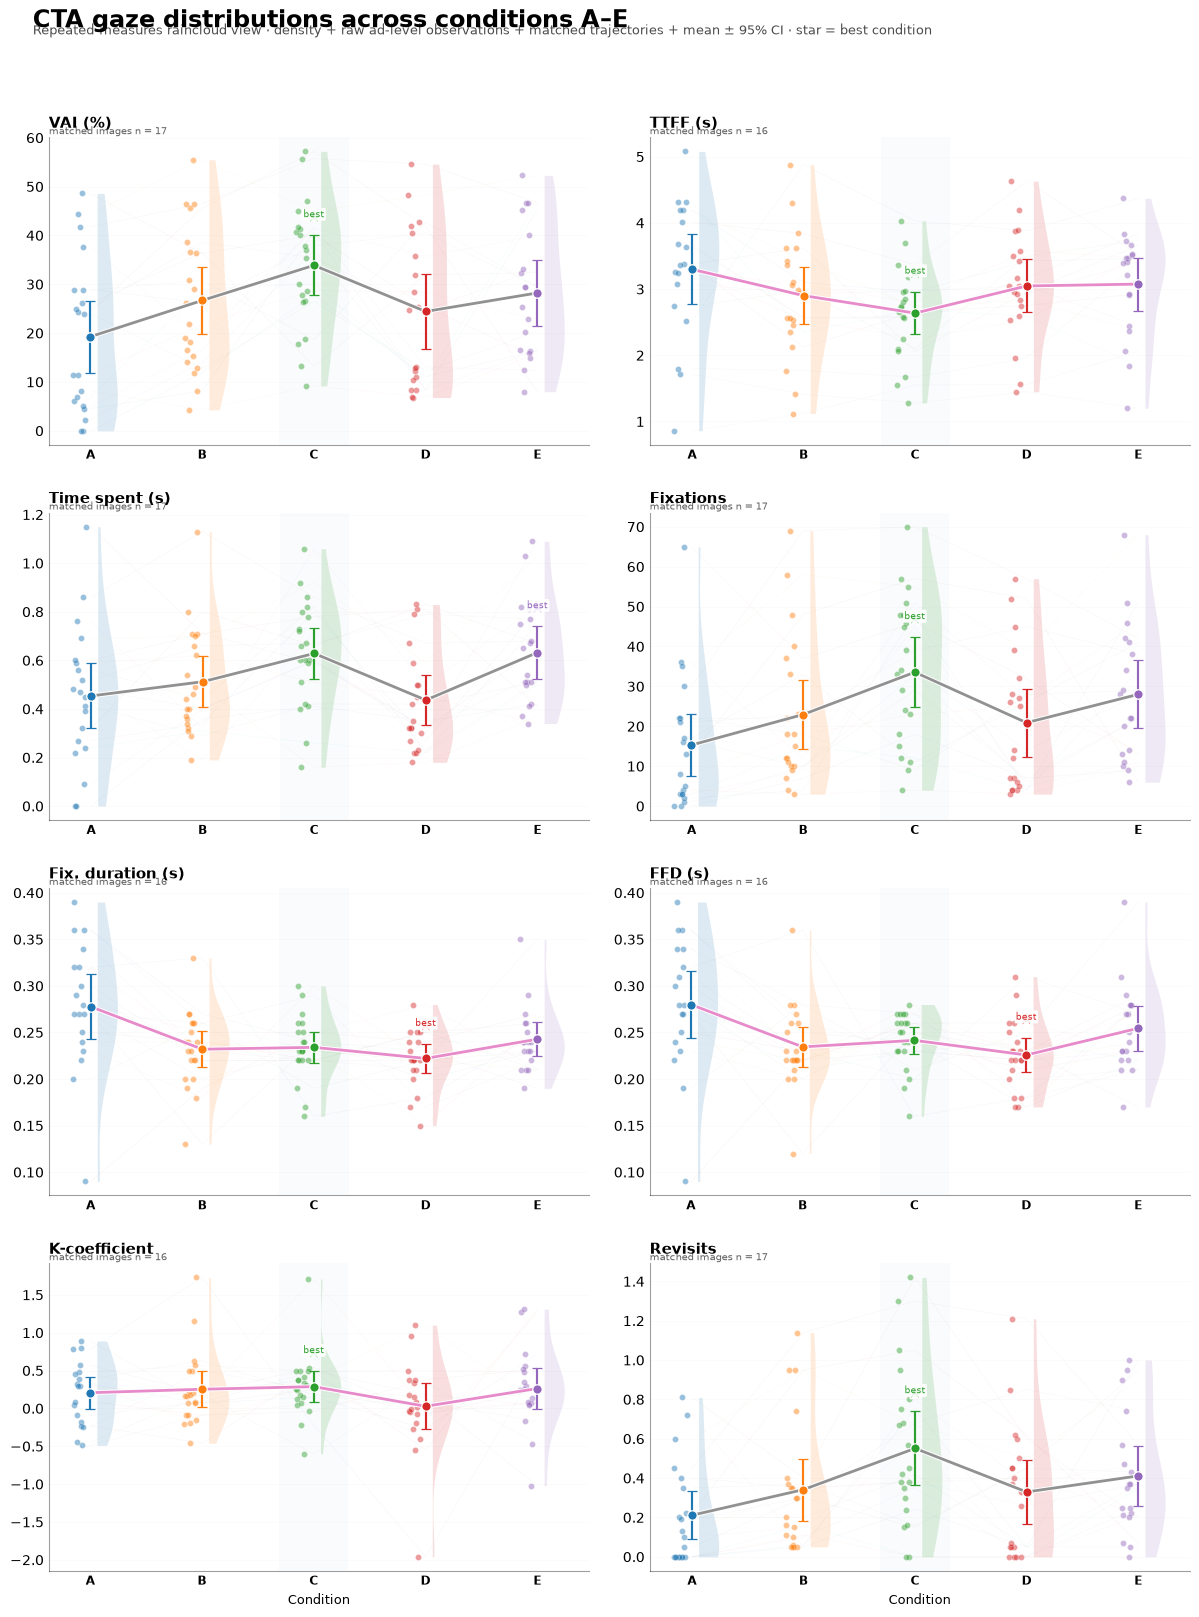

Saved: _raincloud_best_CTA.pdf
Saved: _raincloud_best_CTA.png


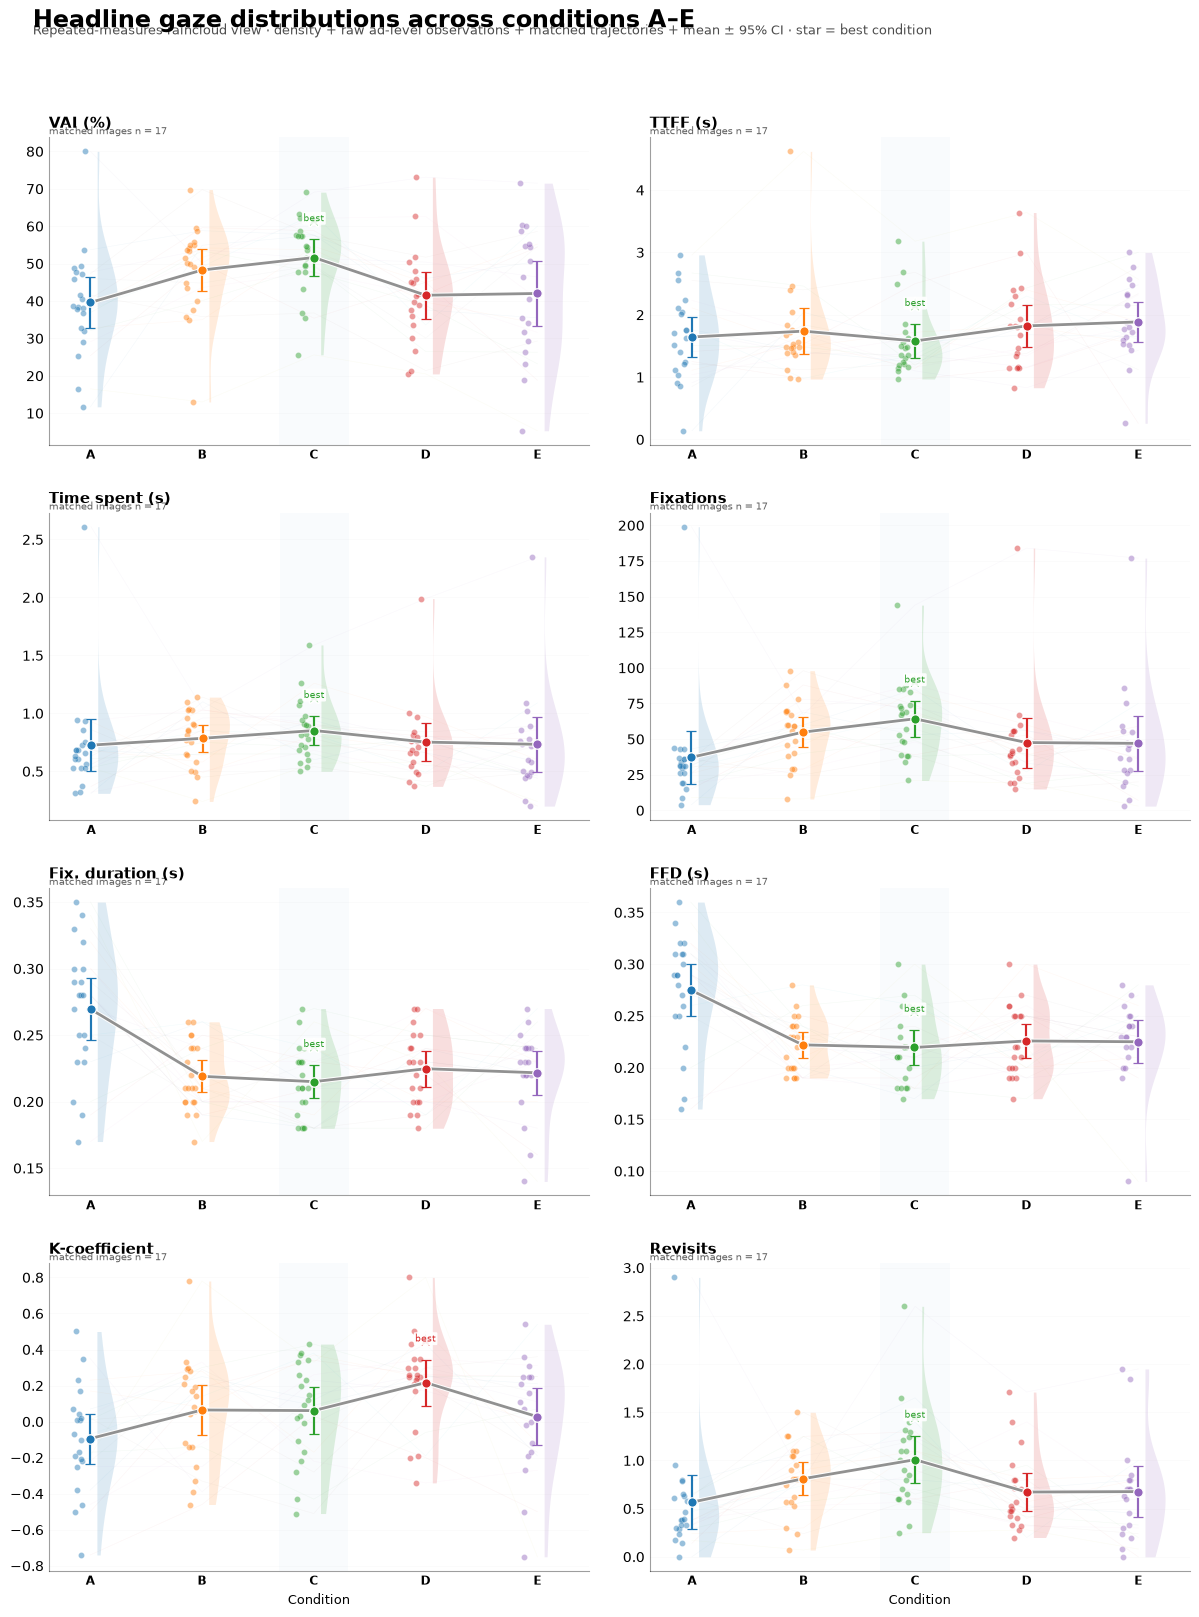

Saved: _raincloud_best_Headline.pdf
Saved: _raincloud_best_Headline.png


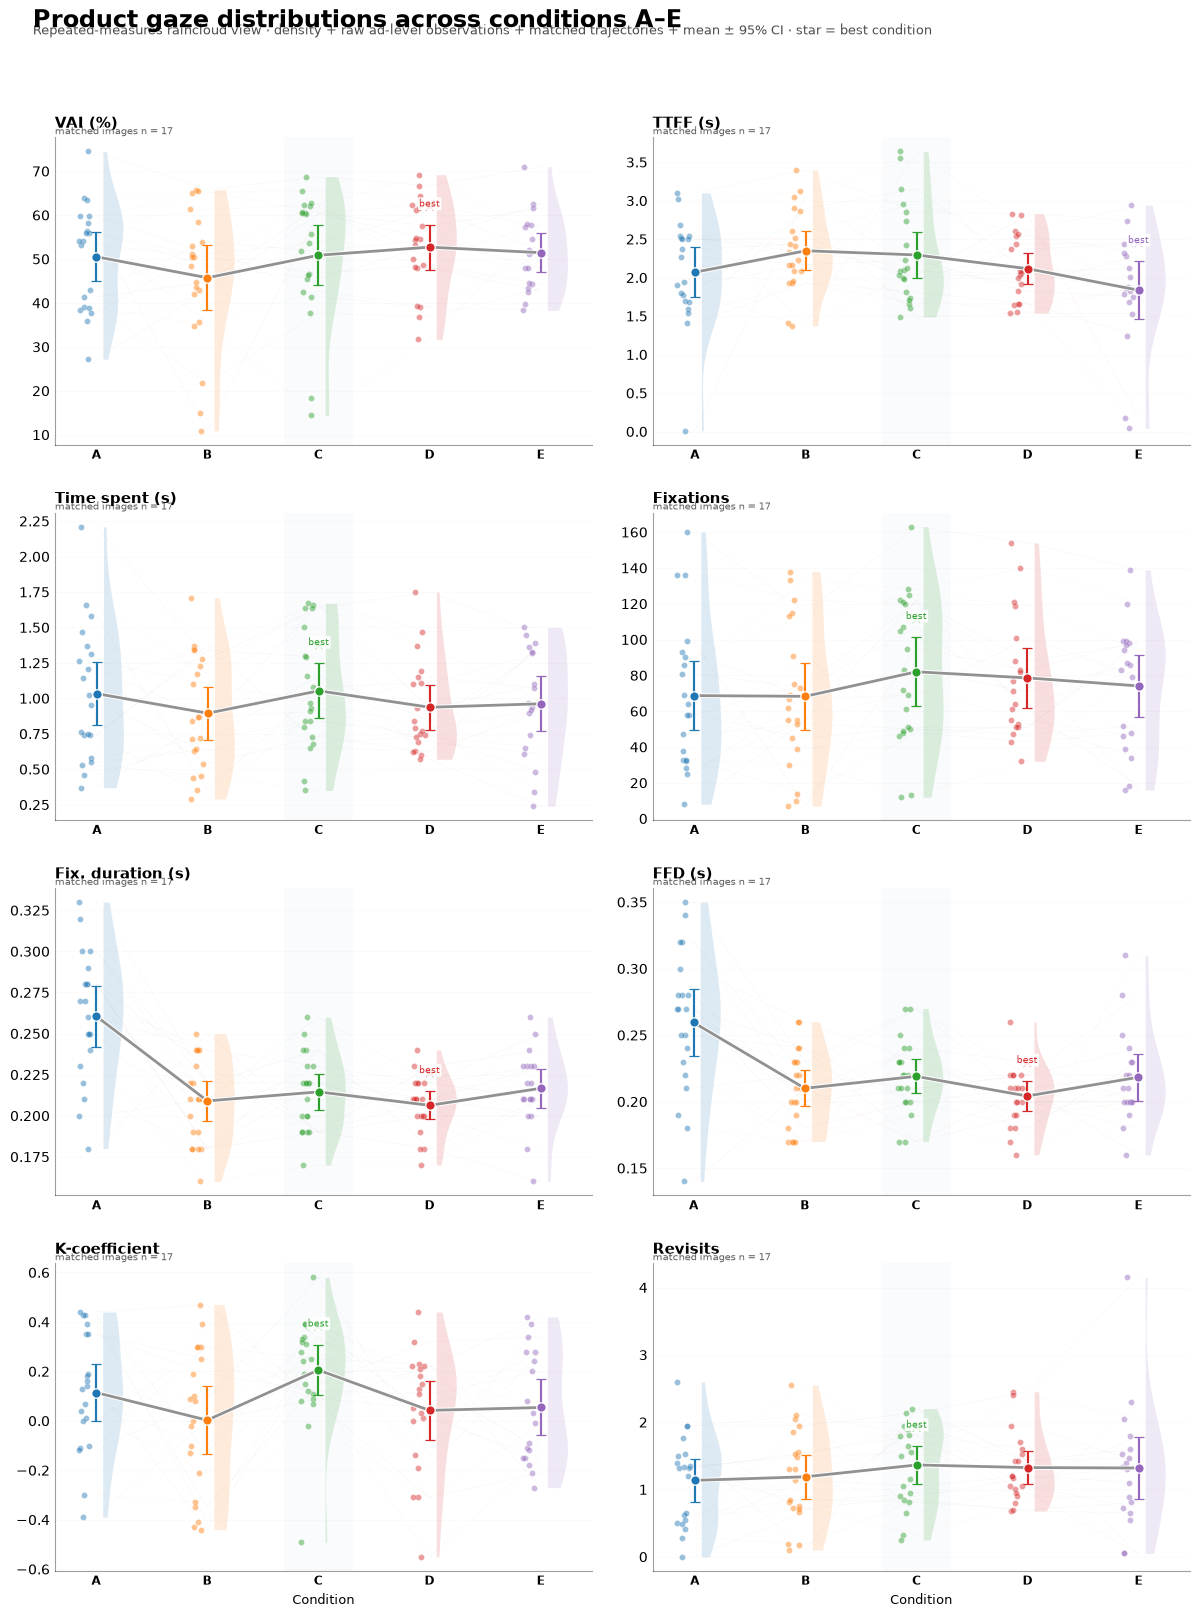

Saved: _raincloud_best_Product.pdf
Saved: _raincloud_best_Product.png


In [16]:
for aoi in AOIS:
    create_raincloud_grid(aoi)


# Figure family B — standardized effect-profile plot with best-condition stars


In [17]:
effect_rows = []
seed_counter = 0

for aoi in AOIS:
    for metric in METRICS:
        focus = get_focus(aoi, metric)
        pivot = get_pivot(focus)

        if "A" not in pivot.columns:
            continue

        for cond in ["B", "C", "D", "E"]:
            pair = pivot[["A", cond]].dropna()

            if len(pair) < 3:
                continue

            dz, lo, hi = bootstrap_dz(
                pair["A"].values,
                pair[cond].values,
                n_boot=N_BOOTSTRAP,
                seed=RANDOM_SEED + seed_counter
            )

            seed_counter += 1

            effect_rows.append({
                "AOI": aoi,
                "metric": metric,
                "condition": cond,
                "n": len(pair),
                "dz": dz,
                "ci_lower": lo,
                "ci_upper": hi,
            })

effects = pd.DataFrame(effect_rows)
effects.head()


,AOI,metric,condition,n,dz,ci_lower,ci_upper
0,CTA,VAI (%),B,20,0.554590,0.134669,1.200406
1,CTA,VAI (%),C,20,0.878400,0.471059,1.503934
2,CTA,VAI (%),D,19,0.436254,-0.013013,1.320612
3,CTA,VAI (%),E,18,0.436764,-0.001279,1.098197
4,CTA,TTFF (s),B,18,-0.486774,-1.224384,-0.020155


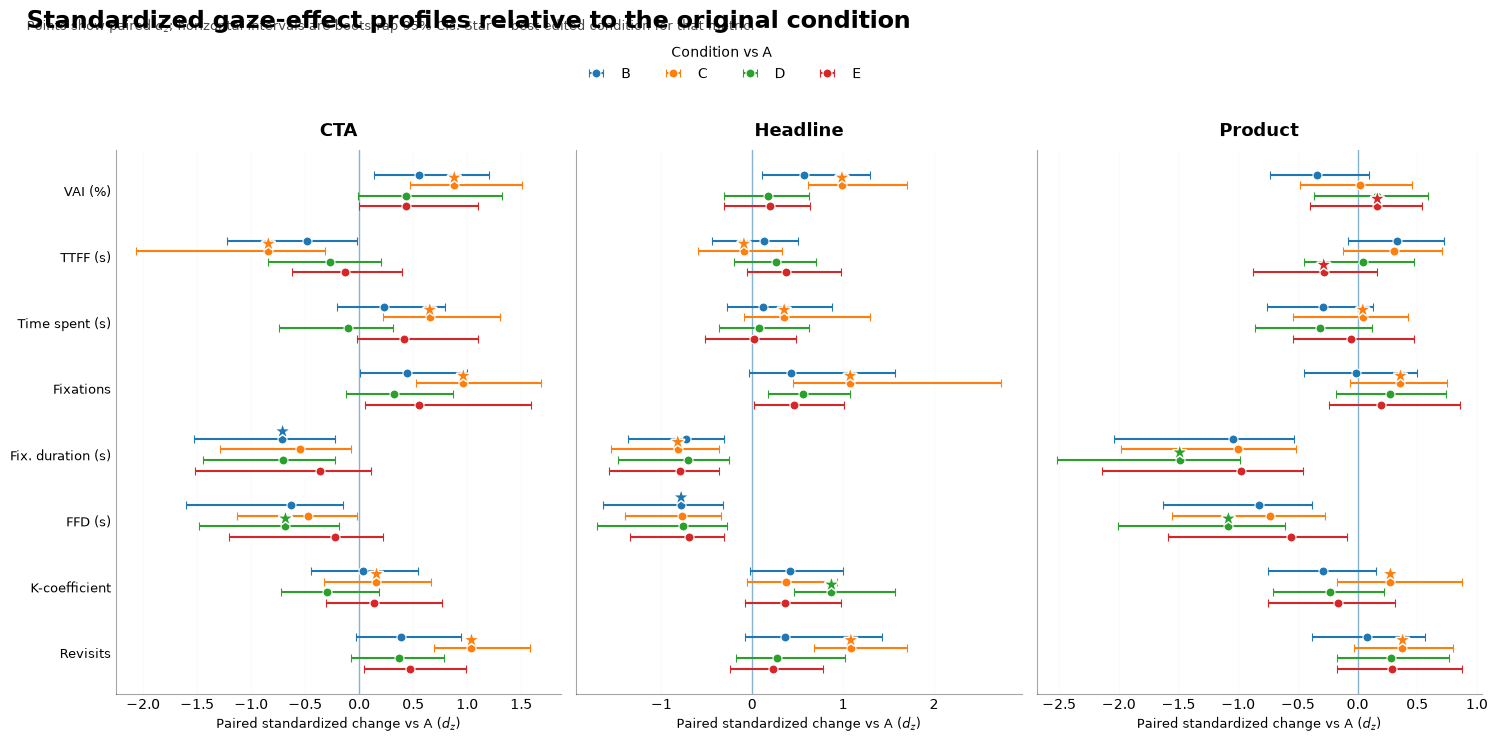

Saved: _effect_profile_best_all_AOIs.pdf
Saved: _effect_profile_best_all_AOIs.png


In [18]:
cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(cycle) < 4:
    cycle = [f"C{i}" for i in range(4)]

cond_colors = {
    "B": cycle[0],
    "C": cycle[1],
    "D": cycle[2],
    "E": cycle[3],
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(15.8, 7.8),
    sharey=True
)

offsets = {
    "B": -0.24,
    "C": -0.08,
    "D": 0.08,
    "E": 0.24,
}

for ax, aoi in zip(axes, AOIS):
    sub = effects[effects["AOI"] == aoi].copy()

    ax.axvline(
        0,
        linewidth=1.0,
        alpha=0.55,
        zorder=1
    )

    # draw the condition effects
    for cond in ["B", "C", "D", "E"]:
        csub = sub[sub["condition"] == cond]

        for i, metric in enumerate(METRICS):
            r = csub[csub["metric"] == metric]

            if len(r) == 0:
                continue

            r = r.iloc[0]
            y = i + offsets[cond]

            left = r["dz"] - r["ci_lower"]
            right = r["ci_upper"] - r["dz"]

            ax.errorbar(
                r["dz"],
                y,
                xerr=np.array([[left], [right]]),
                fmt="o",
                markersize=6.5,
                capsize=3,
                elinewidth=1.5,
                color=cond_colors[cond],
                markeredgecolor="white",
                markeredgewidth=0.8,
                zorder=3,
                label=cond if i == 0 else None
            )

    # add a star for the best condition in each metric
    for i, metric in enumerate(METRICS):
        best_cond = get_best_profile_condition(sub, metric)

        if best_cond is None:
            continue

        r = sub[
            (sub["metric"] == metric)
            & (sub["condition"] == best_cond)
        ]

        if len(r) == 0:
            continue

        r = r.iloc[0]
        y = i + offsets[best_cond]

        ax.text(
            r["dz"],
            y - 0.10,
            "★",
            ha="center",
            va="center",
            fontsize=11.5,
            color=cond_colors[best_cond],
            zorder=4,
            path_effects=[
                pe.Stroke(linewidth=2.2, foreground="white"),
                pe.Normal()
            ]
        )

    ax.set_title(
        aoi,
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(
        "Paired standardized change vs A ($d_z$)",
        fontsize=9.5
    )

    ax.grid(
        axis="x",
        linewidth=0.45,
        alpha=0.10
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.35)
    ax.spines["bottom"].set_alpha(0.35)

    ax.tick_params(length=0)

axes[0].set_yticks(np.arange(len(METRICS)))
axes[0].set_yticklabels(METRICS, fontsize=9)

for ax in axes:
    ax.invert_yaxis()

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Condition vs A",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=4,
    frameon=False
)

fig.suptitle(
    "Standardized gaze-effect profiles relative to the original condition",
    x=0.06,
    y=0.995,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.06,
    0.968,
    "Points show paired $d_z$; horizontal intervals are bootstrap 95% CIs. Star = best edited condition for that metric.",
    fontsize=9.5,
    alpha=0.72
)

fig.tight_layout(
    rect=[0.04, 0.05, 0.995, 0.92]
)

fig.savefig(
    EFFECT_PROFILE_PDF,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    EFFECT_PROFILE_PNG,
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", EFFECT_PROFILE_PDF)
print("Saved:", EFFECT_PROFILE_PNG)


## Outputs

This notebook creates:

### Raincloud distributions with best-condition stars
```text
_raincloud_best_CTA.pdf
_raincloud_best_Headline.pdf
_raincloud_best_Product.pdf
```

### Standardized effect overview with best-condition stars
```text
_effect_profile_best_all_AOIs.pdf
```

If you want to change what counts as “best,” edit the `BEST_RULES` dictionary at the top.
